## 1. LIBRERIAS

In [57]:
import pandas as pd
import numpy as np
import numpy.matlib

import matplotlib.colors

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

#LIBRERIA PLS
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score

from sklearn.metrics import mean_squared_error

from sklearn.model_selection import cross_val_predict

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from scipy.stats import norm

import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.ticker as ticker

## 2. FUNCIONES

In [5]:

def wavelength_to_rgb(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    Additionally alpha value set to 0.5 outside range
    '''
    wavelength = float(wavelength)
    if wavelength >= 380 and wavelength <= 750:
        A = 1.
    else:
        A=0.5
    if wavelength < 380:
        wavelength = 380.
    if wavelength >750:
        wavelength = 750.
    if wavelength >= 380 and wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif wavelength >= 440 and wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif wavelength >= 490 and wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif wavelength >= 510 and wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif wavelength >= 580 and wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif wavelength >= 645 and wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    return (R,G,B,A)


def print_wavelength(axs):
    end=920
    init=370
    clim=(init,end)
    norm = plt.Normalize(*clim)
    wl = np.arange(clim[0],clim[1]+1,1)
    colorlist = list(zip(norm(wl),[wavelength_to_rgb(w) for w in wl]))
    spectralmap = matplotlib.colors.LinearSegmentedColormap.from_list("spectrum", colorlist)

    #fig, axs = plt.subplots(figsize=(8,0.5))
    axs.get_yaxis().set_visible(False)
    #axs.get_xaxis().set_visible(False)
    #axs.YAxis.set_major_formatter(FormatStrFormatter('%.2f'))
    wavelengths = np.linspace(init, end, end-init+1)
    spectrum = np.ones(end-init+1)
    plt.plot(wavelengths, spectrum, color='darkred')

    y = np.linspace(0, 1, 100)
    X,Y = np.meshgrid(wavelengths, y)

    extent=(np.min(wavelengths), np.max(wavelengths), np.min(y), np.max(y))

    plt.imshow(X, clim=clim,  extent=extent, cmap=spectralmap, aspect='auto')
    plt.xlabel('Wavelength (nm)')




    plt.show()

    return

In [6]:
def optimise_pls_cv(X, y, kfold, n_comp):
    # Define PLS object
    pls = PLSRegression(n_components=n_comp)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y,cv=kfold)

    pls.fit(X, y)

    #R2

    y_pred=pls.predict(X)

    # Calculate scores
    q2 = r2_score(y, y_cv)
    r2 = r2_score(y, y_pred)
    #RMSE=mean_squared_error(y, y_cv)**0.5

    return (r2,q2)

def scatterplot(y_real, y_pred,ax):
    ax.scatter(y_real,y_pred)
    val_min=np.min([np.min(y_real.values.tolist()), np.min(y_pred)])
    val_max=np.min([np.max(y_real.values.tolist()), np.max(y_pred)])
    ax.set_title('REAL VS PREDICHO - DATA TRAIN')
    ax.plot([val_min, val_max], [val_min, val_max], ls="-", c="0.1")

    return

def plot_metrics(vals, xticks, ylabel, objective,show):
    with plt.style.context('ggplot'):

        if objective=='min':
            idx = np.argmin(vals)
        else:
            idx = np.argmax(vals)

        if show:
          plt.plot(xticks, np.array(vals), '-v', color='blue', mfc='blue')
          plt.plot(xticks[idx], np.array(vals)[idx], 'P', ms=10, mfc='red')

          plt.xlabel('Number of PLS components')
          plt.xticks = xticks
          plt.ylabel(ylabel)
          plt.title('PLS')

        print("componente seleccionada: ",xticks[idx])
    return xticks[idx]

## 3. LECTURA DE DATOS

In [29]:
data_df = pd.read_excel('BD harina, v2.xlsx')


In [35]:
x = pd.DataFrame(data_df, columns=['B1','B2','B3','B4','B5','B6','B7','B8','B9','B10','B11','B12','B13','B14','B15','B16','B17','B18','B19','B20',
                                   'B21','B22','B23','B24','B25','B26','B27','B28','B29','B30','B31','B32','B33','B34','B35','B36','B37','B38','B39','B40',
                                   'B41','B42','B43','B44','B45','B46','B47','B48','B49','B50','B51','B52','B53','B54','B55','B56','B57','B58','B59','B60',
                                   'B61','B62','B63','B64','B65','B66','B67','B68','B69','B70','B71','B72','B73','B74','B75','B76','B77','B78','B79','B80',
                                   'B81','B82','B83','B84','B85','B86','B87','B88','B89','B90','B91','B92','B93','B94','B95','B96','B97','B98','B99','B100',
                                   'B101','B102','B103','B104','B105','B106','B107','B108','B109','B110','B111','B112','B113','B114','B115','B116','B117','B118','B119','B120',
                                   'B121','B122','B123','B124','B125','B126','B127','B128','B129','B130','B131','B132','B133','B134','B135','B136','B137','B138','B139','B140',
                                   'B141','B142','B143','B144','B145','B146','B147','B148','B149','B150','B151','B152','B153','B154','B155','B156','B157','B158','B159','B160',
                                   'B161','B162','B163','B164','B165','B166','B167','B168','B169','B170','B171','B172','B173','B174','B175','B176','B177','B178','B179','B180',
                                   'B181','B182','B183','B184','B185','B186','B187','B188','B189','B190','B191','B192','B193','B194','B195','B196','B197','B198','B199','B200',
                                   'B201','B202','B203','B204','B205','B206','B207','B208','B209','B210','B211','B212','B213','B214','B215','B216','B217','B218','B219','B220',
                                   'B221','B222','B223','B224','B225','B226','B227','B228','B229','B230','B231','B232','B233','B234','B235','B236','B237','B238','B239','B240'])



labels=[394.35,396.4374,398.5248,400.6122,402.6996,404.787,406.8744,408.9618,411.0492,413.1366,415.224,417.3114,419.3988,421.4862,423.5736,425.661,427.7484,429.8358,431.9232,434.0106,436.098,438.1854,440.2728,442.3602,444.4476,446.535,448.6224,450.7098,452.7972,454.8846,456.972,459.0594,461.1468,463.2342,465.3216,467.409,469.4964,471.5838,473.6712,475.7586,477.846,479.9334,482.0208,484.1082,486.1956,488.283,490.3704,492.4578,494.5452,496.6326,498.72,500.8074,502.8948,504.9822,507.0696,509.157,511.2444,513.3318,515.4192,517.5066,519.594,521.6814,523.7688,525.8562,527.9436,530.031,532.1184,534.2058,536.2932,538.3806,540.468,542.5554,544.6428,546.7302,548.8176,550.905,552.9924,555.0798,557.1672,559.2546,561.342,563.4294,565.5168,567.6042,569.6916,571.779,573.8664,575.9538,578.0412,580.1286,582.216,584.3034,586.3908,588.4782,590.5656,592.653,594.7404,596.8278,598.9152,601.0026,603.09,605.1774,607.2648,609.3522,611.4396,613.527,615.6144,617.7018,619.7892,621.8766,623.964,626.0514,628.1388,630.2262,632.3136,634.401,636.4884,638.5758,640.6632,642.7506,644.838,646.9254,649.0128,651.1002,653.1876,655.275,657.3624,659.4498,661.5372,663.6246,665.712,667.7994,669.8868,671.9742,674.0616,676.149,678.2364,680.3238,682.4112,684.4986,686.586,688.6734,690.7608,692.8482,694.9356,697.023,699.1104,701.1978,703.2852,705.3726,707.46,709.5474,711.6348,713.7222,715.8096,717.897,719.9844,722.0718,724.1592,726.2466,728.334,730.4214,732.5088,734.5962,736.6836,738.771,740.8584,742.9458,745.0332,747.1206,749.208,751.2954,753.3828,755.4702,757.5576,759.645,761.7324,763.8198,765.9072,767.9946,770.082,772.1694,774.2568,776.3442,778.4316,780.519,782.6064,784.6938,786.7812,788.8686,790.956,793.0434,795.1308,797.2182,799.3056,801.393,803.4804,805.5678,807.6552,809.7426,811.83,813.9174,816.0048,818.0922,820.1796,822.267,824.3544,826.4418,828.5292,830.6166,832.704,834.7914,836.8788,838.9662,841.0536,843.141,845.2284,847.3158,849.4032,851.4906,853.578,855.6654,857.7528,859.8402,861.9276,864.015,866.1024,868.1898,870.2772,872.3646,874.452,876.5394,878.6268,880.7142,882.8016,884.889,886.9764,889.0638,891.1512,893.2386]

y = pd.DataFrame(data_df, columns=['PROTEINA'])

error_PLS_GSMW = pd.read_excel('record-PLS-GSMW.xlsx')
error_PLS_VIP = pd.read_excel('record-PLS-VIP.xlsx')
error_PLS_BVE = pd.read_excel('record-PLS-BVE.xlsx')


In [36]:
max_protein=np.max(y)
min_protein=np.min(y)
mean_protein=np.mean(y)
median_protein=np.median(y)

print(min_protein)
print(max_protein)

65.51
70.79


## 4. DESCRIPCION DE DATOS

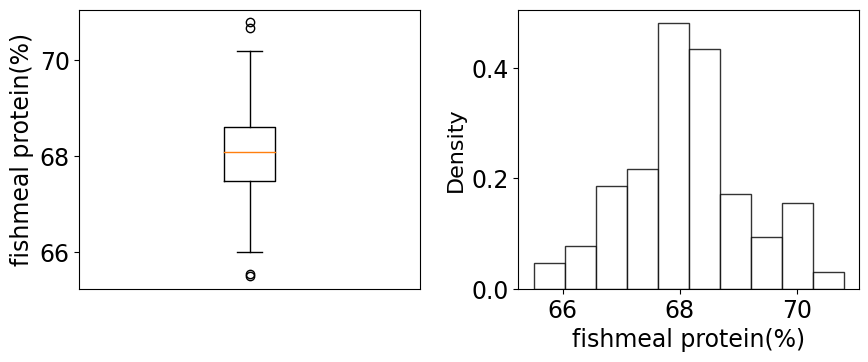

In [41]:
t1=np.arange(0,2.5,0.1)
plt.rcParams.update({'font.size': 17})

fig = plt.figure(figsize =(9, 4))

ax1 = fig.add_subplot(1, 2, 1)
plt.boxplot(y)
ax1.get_xaxis().set_visible(False)
plt.ylabel('fishmeal protein(%)');

ax2 = fig.add_subplot(1, 2, 2)

plt.hist(y, density=True, bins=10, color="white",edgecolor='black', alpha=0.8)  # density=False would make counts


#plt.axvline(x=0.8, color="r", label="maximum limit",linestyle='--',linewidth=1.5) # 0.8 is maximun concentration for cadmiun
#plt.axvline(x=list(mean_cd), color="b", label="average",linestyle='-.',linewidth=1.5)
#plt.axvline(x=median_cd, color="k", label="median",linewidth=2)
plt.ylabel('Density', fontsize=16)
plt.xlabel('fishmeal protein(%)');
plt.tight_layout()

#plt.text(1.5, 0.6, '{0:.2f}%'.format(len(filter_y)/len(y)*100),fontsize="medium") #x,y are position
#ax2.legend()

#ax2.fill_between(t1,1.2, where=t1>= 0.8, facecolor='red', alpha=0.1)

plt.savefig('Fig 1.png', dpi=1200, bbox_inches = 'tight')






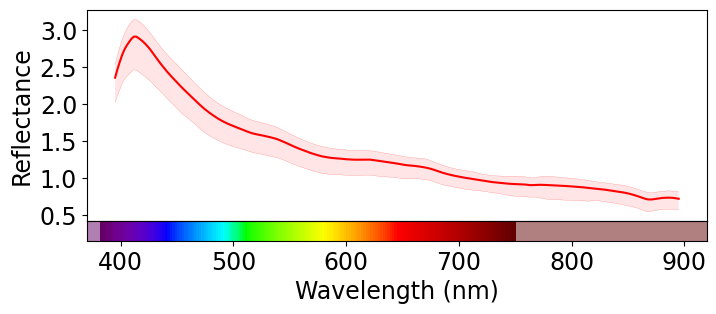

In [64]:
w1 =[394.35,396.4374,398.5248,400.6122,402.6996,404.787,406.8744,408.9618,411.0492,413.1366,415.224,417.3114,419.3988,421.4862,423.5736,425.661,427.7484,429.8358,431.9232,434.0106,436.098,438.1854,440.2728,442.3602,444.4476,446.535,448.6224,450.7098,452.7972,454.8846,456.972,459.0594,461.1468,463.2342,465.3216,467.409,469.4964,471.5838,473.6712,475.7586,477.846,479.9334,482.0208,484.1082,486.1956,488.283,490.3704,492.4578,494.5452,496.6326,498.72,500.8074,502.8948,504.9822,507.0696,509.157,511.2444,513.3318,515.4192,517.5066,519.594,521.6814,523.7688,525.8562,527.9436,530.031,532.1184,534.2058,536.2932,538.3806,540.468,542.5554,544.6428,546.7302,548.8176,550.905,552.9924,555.0798,557.1672,559.2546,561.342,563.4294,565.5168,567.6042,569.6916,571.779,573.8664,575.9538,578.0412,580.1286,582.216,584.3034,586.3908,588.4782,590.5656,592.653,594.7404,596.8278,598.9152,601.0026,603.09,605.1774,607.2648,609.3522,611.4396,613.527,615.6144,617.7018,619.7892,621.8766,623.964,626.0514,628.1388,630.2262,632.3136,634.401,636.4884,638.5758,640.6632,642.7506,644.838,646.9254,649.0128,651.1002,653.1876,655.275,657.3624,659.4498,661.5372,663.6246,665.712,667.7994,669.8868,671.9742,674.0616,676.149,678.2364,680.3238,682.4112,684.4986,686.586,688.6734,690.7608,692.8482,694.9356,697.023,699.1104,701.1978,703.2852,705.3726,707.46,709.5474,711.6348,713.7222,715.8096,717.897,719.9844,722.0718,724.1592,726.2466,728.334,730.4214,732.5088,734.5962,736.6836,738.771,740.8584,742.9458,745.0332,747.1206,749.208,751.2954,753.3828,755.4702,757.5576,759.645,761.7324,763.8198,765.9072,767.9946,770.082,772.1694,774.2568,776.3442,778.4316,780.519,782.6064,784.6938,786.7812,788.8686,790.956,793.0434,795.1308,797.2182,799.3056,801.393,803.4804,805.5678,807.6552,809.7426,811.83,813.9174,816.0048,818.0922,820.1796,822.267,824.3544,826.4418,828.5292,830.6166,832.704,834.7914,836.8788,838.9662,841.0536,843.141,845.2284,847.3158,849.4032,851.4906,853.578,855.6654,857.7528,859.8402,861.9276,864.015,866.1024,868.1898,870.2772,872.3646,874.452,876.5394,878.6268,880.7142,882.8016,884.889,886.9764,889.0638,891.1512,893.2386]

plt.rcParams.update({'font.size': 17})

fig, ax = plt.subplots(2, figsize=(8,3), height_ratios=[11, 1])
plt.subplots_adjust(wspace=0, hspace=0)
#axs[0] = fig.add_subplot(2, 1, 1)

ax[0].plot(w1,np.mean(x,0),color="r",linewidth=1.5)
ax[0].plot(w1,np.max(x,0),color="r",linewidth=0.1)
ax[0].plot(w1,np.min(x,0),color="r",linewidth=0.1)
ax[0].yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax[0].get_xaxis().set_visible(False)
ax[0].set_xlabel("Wavelengths (nm)")
ax[0].set_ylabel("Reflectance")
#plt.title("Spectral signature")

ax[0].fill_between(w1,np.min(x,0),np.max(x,0), facecolor='red', alpha=0.1)

#axs[1] = fig.add_subplot(2, 1, 2)
print_wavelength(ax[1])



fig.savefig('Fig 2.png', dpi=1200, bbox_inches = 'tight')

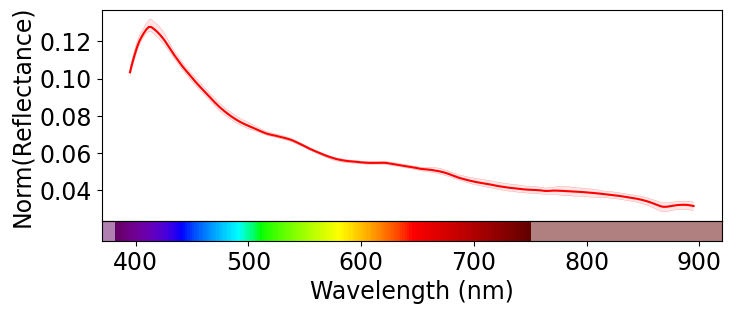

In [62]:
transformer = Normalizer().fit(x)

x_new = transformer.transform(x)

w1 =[394.35,396.4374,398.5248,400.6122,402.6996,404.787,406.8744,408.9618,411.0492,413.1366,415.224,417.3114,419.3988,421.4862,423.5736,425.661,427.7484,429.8358,431.9232,434.0106,436.098,438.1854,440.2728,442.3602,444.4476,446.535,448.6224,450.7098,452.7972,454.8846,456.972,459.0594,461.1468,463.2342,465.3216,467.409,469.4964,471.5838,473.6712,475.7586,477.846,479.9334,482.0208,484.1082,486.1956,488.283,490.3704,492.4578,494.5452,496.6326,498.72,500.8074,502.8948,504.9822,507.0696,509.157,511.2444,513.3318,515.4192,517.5066,519.594,521.6814,523.7688,525.8562,527.9436,530.031,532.1184,534.2058,536.2932,538.3806,540.468,542.5554,544.6428,546.7302,548.8176,550.905,552.9924,555.0798,557.1672,559.2546,561.342,563.4294,565.5168,567.6042,569.6916,571.779,573.8664,575.9538,578.0412,580.1286,582.216,584.3034,586.3908,588.4782,590.5656,592.653,594.7404,596.8278,598.9152,601.0026,603.09,605.1774,607.2648,609.3522,611.4396,613.527,615.6144,617.7018,619.7892,621.8766,623.964,626.0514,628.1388,630.2262,632.3136,634.401,636.4884,638.5758,640.6632,642.7506,644.838,646.9254,649.0128,651.1002,653.1876,655.275,657.3624,659.4498,661.5372,663.6246,665.712,667.7994,669.8868,671.9742,674.0616,676.149,678.2364,680.3238,682.4112,684.4986,686.586,688.6734,690.7608,692.8482,694.9356,697.023,699.1104,701.1978,703.2852,705.3726,707.46,709.5474,711.6348,713.7222,715.8096,717.897,719.9844,722.0718,724.1592,726.2466,728.334,730.4214,732.5088,734.5962,736.6836,738.771,740.8584,742.9458,745.0332,747.1206,749.208,751.2954,753.3828,755.4702,757.5576,759.645,761.7324,763.8198,765.9072,767.9946,770.082,772.1694,774.2568,776.3442,778.4316,780.519,782.6064,784.6938,786.7812,788.8686,790.956,793.0434,795.1308,797.2182,799.3056,801.393,803.4804,805.5678,807.6552,809.7426,811.83,813.9174,816.0048,818.0922,820.1796,822.267,824.3544,826.4418,828.5292,830.6166,832.704,834.7914,836.8788,838.9662,841.0536,843.141,845.2284,847.3158,849.4032,851.4906,853.578,855.6654,857.7528,859.8402,861.9276,864.015,866.1024,868.1898,870.2772,872.3646,874.452,876.5394,878.6268,880.7142,882.8016,884.889,886.9764,889.0638,891.1512,893.2386]

plt.rcParams.update({'font.size': 17})

fig, ax = plt.subplots(2, figsize=(8,3), height_ratios=[11, 1])
plt.subplots_adjust(wspace=0, hspace=0)
#axs[0] = fig.add_subplot(2, 1, 1)

ax[0].plot(w1,np.mean(x_new,0),color="r",linewidth=1.5)
ax[0].plot(w1,np.max(x_new,0),color="r",linewidth=0.1)
ax[0].plot(w1,np.min(x_new,0),color="r",linewidth=0.1)
ax[0].yaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax[0].get_xaxis().set_visible(False)
ax[0].set_xlabel("Wavelengths (nm)")
ax[0].set_ylabel("Norm(Reflectance)")
#plt.title("Spectral signature")

ax[0].fill_between(w1,np.min(x_new,0),np.max(x_new,0), facecolor='red', alpha=0.1)

#axs[1] = fig.add_subplot(2, 1, 2)
print_wavelength(ax[1])



fig.savefig('Fig 3.png', dpi=1200, bbox_inches = 'tight')


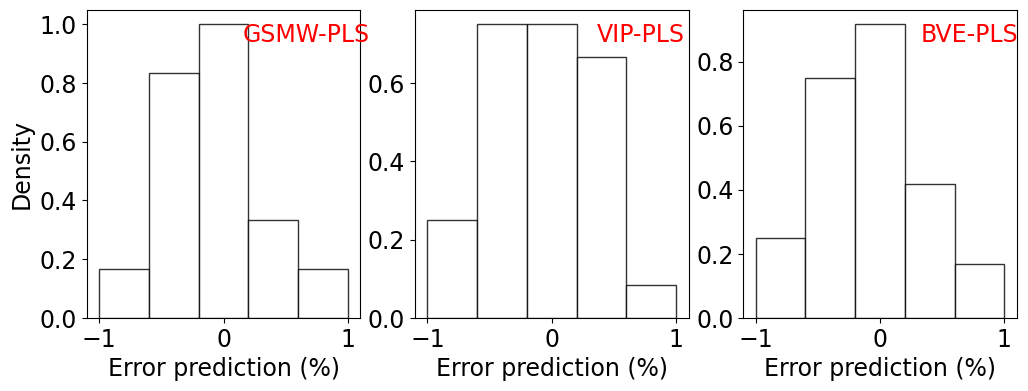

In [33]:
plt.rcParams.update({'font.size': 17})

fig = plt.figure(figsize =(12, 4))

ax1 = fig.add_subplot(1, 3, 1)
y_pred = pd.DataFrame(error_PLS_GSMW, columns=['Predicted']).to_numpy()
y = pd.DataFrame(error_PLS_GSMW, columns=['PROTEINA']).to_numpy()
plt.hist(y-y_pred, density=True, bins=5, color="white",edgecolor='black', alpha=0.8,range=[-1, 1])  # density=False would make counts
ax1.set_xlabel("Error prediction (%)")
ax1.set_ylabel("Density")
fig.text(0.255, 0.8, 'GSMW-PLS', {'color': 'r'})

ax2 = fig.add_subplot(1, 3, 2)
y_pred = pd.DataFrame(error_PLS_VIP, columns=['Predicted']).to_numpy()
y = pd.DataFrame(error_PLS_VIP, columns=['PROTEINA']).to_numpy()
plt.hist(y-y_pred, density=True, bins=5, color="white",edgecolor='black', alpha=0.8,range=[-1, 1])  # density=False would make counts
ax2.set_xlabel("Error prediction (%)")
#ax2.set_ylabel("Density", fontsize=14)
fig.text(0.55, 0.8, 'VIP-PLS', {'color': 'r'})

ax3 = fig.add_subplot(1, 3, 3)
y_pred = pd.DataFrame(error_PLS_BVE, columns=['Predicted']).to_numpy()
y = pd.DataFrame(error_PLS_BVE, columns=['PROTEINA']).to_numpy()
plt.hist(y-y_pred, density=True, bins=5, color="white",edgecolor='black', alpha=0.8,range=[-1, 1])  # density=False would make counts
ax3.set_xlabel("Error prediction (%)")
#ax3.set_ylabel("Density", fontsize=14)
fig.text(0.82, 0.8, 'BVE-PLS', {'color': 'r'})

fig.savefig('Fig 7.png', dpi=1200, bbox_inches = 'tight')